# Modelos de Árboles en Machine Learning: Guía Práctica y Comparativa

Este notebook presenta una implementación práctica y comparación de las cinco familias principales de algoritmos basados en árboles de decisión, siguiendo la siguiente estructura conceptual:

| Familia | Combinación de Árboles | Qué Reduce | Ejemplo Industrial |
| :--- | :--- | :--- | :--- |
| **Single Tree (Árbol Único)** | — | Nada (Nothing) | `sklearn DecisionTree` |
| **Bagging** | Paralelo + Votación | Varianza | `BaggingClassifier` |
| **Random Forest** | Paralelo + Votación + Diversidad | Varianza (aún más) | `RandomForestClassifier` |
| **Boosting (AdaBoost)** | Secuencial + Pesos | Sesgo (Bias) | `AdaBoostClassifier` |
| **Gradient Boosting** | Secuencial + Residuos | Sesgo (Bias) | `XGBoost, LightGBM, CatBoost` |

Utilizaremos el conjunto de datos de pingüinos (`penguins_size.csv`) para clasificar la especie de pingüino a partir de sus características físicas.

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Ajustes de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Preprocesamiento de Datos
Cargamos el dataset `penguins_size.csv`, removemos valores nulos e inválidos, y codificamos las variables categóricas.

In [2]:
# Carga del dataset
df = pd.read_csv('penguins_size.csv')
print(f"Dimensiones iniciales del dataset: {df.shape}")

# Limpieza de nulos y valores inválidos
df = df.dropna()
df = df[df['sex'] != '.']
print(f"Dimensiones después de la limpieza: {df.shape}")

# Codificación de variables de entrada (X) y objetivo (y)
X = df.drop('species', axis=1)
y = df['species']

# Codificar la variable objetivo (especie de pingüino)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes_names = le.classes_

# Codificar las variables categóricas de entrada usando pandas One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("\nPrimeras filas del conjunto procesado:")
display(X_encoded.head())

# División de datos en Train y Test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nDatos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Dimensiones iniciales del dataset: (344, 7)
Dimensiones después de la limpieza: (333, 7)

Primeras filas del conjunto procesado:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True



Datos de entrenamiento: (266, 7)
Datos de prueba: (67, 7)


## 3. Modelo 1: Single Tree (Árbol Único)
Un árbol de decisión simple divide el espacio de características en regiones. Suele tener **alta varianza** si se deja crecer sin límites.

In [3]:
# Inicializar y entrenar el modelo
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

# Predicción
y_pred_st = single_tree.predict(X_test)
acc_st = accuracy_score(y_test, y_pred_st)

print("Exactitud (Accuracy):", acc_st)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_st, target_names=classes_names))

Exactitud (Accuracy): 0.9552238805970149

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



## 4. Modelo 2: Bagging
Bagging (Bootstrap Aggregating) entrena múltiples estimadores en paralelo usando muestras bootstrap del conjunto original. Combina sus predicciones por votación mayoritaria y **reduce principalmente la varianza**.

In [4]:
# Inicializar y entrenar el modelo
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging_model.fit(X_train, y_train)

# Predicción
y_pred_bag = bagging_model.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Exactitud (Accuracy):", acc_bag)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_bag, target_names=classes_names))

Exactitud (Accuracy): 0.9850746268656716

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.99        67



## 5. Modelo 3: Random Forest
Random Forest es una extensión de Bagging que añade **diversidad** al seleccionar solo un subconjunto aleatorio de características en cada división, logrando **reducir aún más la varianza** en comparación con árboles de decisión estándar.

In [5]:
# Inicializar y entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Exactitud (Accuracy):", acc_rf)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=classes_names))

Exactitud (Accuracy): 1.0

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



## 6. Modelo 4: Boosting (AdaBoost)
AdaBoost (Adaptive Boosting) es un modelo secuencial que asigna **pesos** a las instancias. En cada paso, entrena un estimador débil (típicamente stumps) enfocándose en los ejemplos que el estimador anterior clasificó incorrectamente. **Reduce principalmente el sesgo (bias)**.

In [6]:
# Inicializar y entrenar el modelo
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train, y_train)

# Predicción
y_pred_ada = adaboost_model.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

print("Exactitud (Accuracy):", acc_ada)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_ada, target_names=classes_names))

Exactitud (Accuracy): 0.9701492537313433

Reporte de Clasificación:


              precision    recall  f1-score   support

      Adelie       1.00      0.93      0.96        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.97        67
   macro avg       0.96      0.98      0.97        67
weighted avg       0.97      0.97      0.97        67



## 7. Modelo 5: Gradient Boosting
Gradient Boosting es un enfoque secuencial que optimiza una función de pérdida entrenando estimadores de forma aditiva para predecir los **residuos (errores)** cometidos por los modelos anteriores. **Reduce principalmente el sesgo (bias)**.

Veremos tres de las implementaciones más famosas y eficientes utilizadas en la industria: **XGBoost**, **LightGBM**, y **CatBoost**.

In [7]:
# A. XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# B. LightGBM
lgb_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

# C. CatBoost
cat_model = CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
acc_cat = accuracy_score(y_test, y_pred_cat)

print(f"Exactitud XGBoost:      {acc_xgb:.4f}")
print(f"Exactitud LightGBM:     {acc_lgb:.4f}")
print(f"Exactitud CatBoost:     {acc_cat:.4f}")

Exactitud XGBoost:      1.0000
Exactitud LightGBM:     1.0000
Exactitud CatBoost:     1.0000


## 8. Comparativa Final de Modelos
Resumimos las exactitudes logradas por cada familia de modelos y las visualizamos en una gráfica comparativa.

,Familia / Modelo,Método de Combinación,Reducción Principal,Exactitud (Accuracy)
0,Random Forest (RandomForestClassifier),Paralelo + Votación + Diversidad,Varianza (más),1.000000
1,Gradient Boosting (LightGBM),Secuencial + Residuos,Sesgo,1.000000
2,Gradient Boosting (XGBoost),Secuencial + Residuos,Sesgo,1.000000
3,Gradient Boosting (CatBoost),Secuencial + Residuos,Sesgo,1.000000
4,Bagging (BaggingClassifier),Paralelo + Votación,Varianza,0.985075
5,Boosting (AdaBoostClassifier),Secuencial + Pesos,Sesgo,0.970149
6,Single Tree (DecisionTree),—,Nada,0.955224


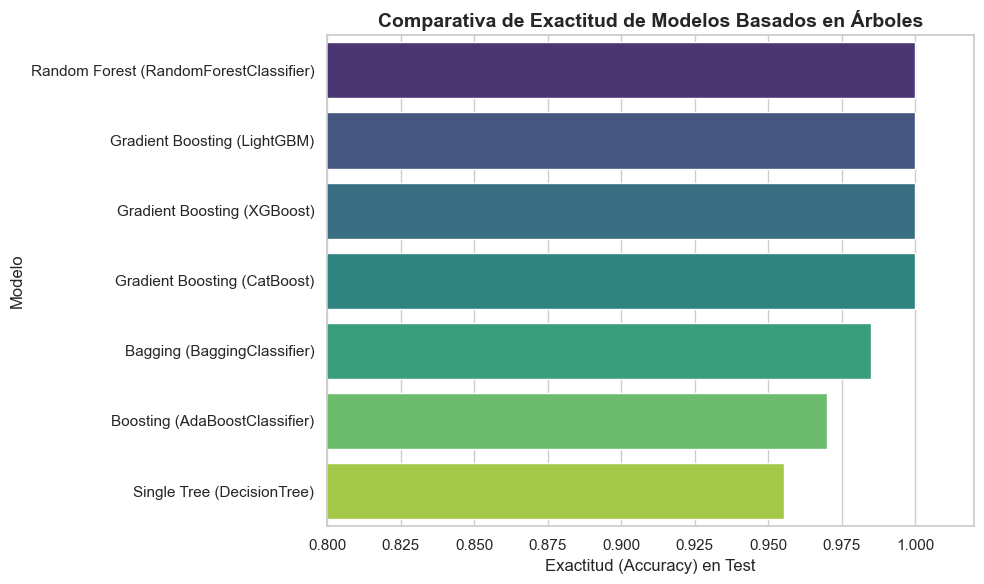

In [8]:
# Crear DataFrame de resultados
results = pd.DataFrame({
    'Familia / Modelo': [
        'Single Tree (DecisionTree)', 
        'Bagging (BaggingClassifier)', 
        'Random Forest (RandomForestClassifier)', 
        'Boosting (AdaBoostClassifier)', 
        'Gradient Boosting (XGBoost)', 
        'Gradient Boosting (LightGBM)', 
        'Gradient Boosting (CatBoost)'
    ],
    'Método de Combinación': [
        '—', 
        'Paralelo + Votación', 
        'Paralelo + Votación + Diversidad', 
        'Secuencial + Pesos', 
        'Secuencial + Residuos', 
        'Secuencial + Residuos', 
        'Secuencial + Residuos'
    ],
    'Reducción Principal': [
        'Nada', 
        'Varianza', 
        'Varianza (más)', 
        'Sesgo', 
        'Sesgo', 
        'Sesgo', 
        'Sesgo'
    ],
    'Exactitud (Accuracy)': [acc_st, acc_bag, acc_rf, acc_ada, acc_xgb, acc_lgb, acc_cat]
})

# Mostrar la tabla ordenada por exactitud
display(results.sort_values(by='Exactitud (Accuracy)', ascending=False).reset_index(drop=True))

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Exactitud (Accuracy)', 
    y='Familia / Modelo', 
    data=results.sort_values(by='Exactitud (Accuracy)', ascending=False),
    palette='viridis'
)
plt.title('Comparativa de Exactitud de Modelos Basados en Árboles', fontsize=14, fontweight='bold')
plt.xlim(0.8, 1.02)
plt.xlabel('Exactitud (Accuracy) en Test', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.tight_layout()
plt.show()